In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score, classification_report
from tqdm import tqdm
import json
from typing import Optional, Tuple
import os

# Set device
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

Device: cpu


/home/rendred/Temporal/.venv-310/lib/python3.10/site-packages/torch/cuda/__init__.py:107: UserWarning: CUDA initialization: CUDA unknown error - this may be due to an incorrectly set up environment, e.g. changing env variable CUDA_VISIBLE_DEVICES after program start. Setting the available devices to be zero. (Triggered internally at ../c10/cuda/CUDAFunctions.cpp:109.)
  return torch._C._cuda_getDeviceCount() > 0


In [2]:
TENSOR_DIR = 'tensors_gpt/'  # Update to your path

# Load metadata
with open('tensors_rep/metadata.json', 'r') as f:
    metadata = json.load(f)

# Load tensors
X_train = np.load(TENSOR_DIR + 'X_train.npy')
X_val = np.load(TENSOR_DIR + 'X_val.npy')
X_test = np.load(TENSOR_DIR + 'X_test.npy')
y_train = np.load(TENSOR_DIR + 'y_train.npy')
y_val = np.load(TENSOR_DIR + 'y_val.npy')
y_test = np.load(TENSOR_DIR + 'y_test.npy')
mask_train = np.load(TENSOR_DIR + 'mask_train.npy')
mask_val = np.load(TENSOR_DIR + 'mask_val.npy')
mask_test = np.load(TENSOR_DIR + 'mask_test.npy')

# Get feature lists
original_features = metadata['original_features']   # 15 features
gap_features = metadata['gap_features']             # 15 features
all_features = metadata['all_features']             # 30 features
T = metadata['T']

print(f"X_train: {X_train.shape}  (N, T, F)")
print(f"mask_train: {mask_train.shape}")
print(f"y_train: {y_train.shape}")
print(f"Train mortality: {y_train.mean()*100:.1f}%")
print(f"Features: {len(all_features)} total ({len(original_features)} original + {len(gap_features)} time gaps)")

X_train: (45756, 48, 30)  (N, T, F)
mask_train: (45756, 48)
y_train: (45756,)
Train mortality: 11.0%
Features: 30 total (15 original + 15 time gaps)


In [37]:
def remove_zero_mask_samples(X, mask, y):
    valid = mask.sum(axis=1) > 0
    print(f"Removing {(~valid).sum()} samples with zero valid hours")
    return X[valid], mask[valid], y[valid]

X_train, mask_train, y_train = remove_zero_mask_samples(X_train, mask_train, y_train)
X_val, mask_val, y_val = remove_zero_mask_samples(X_val, mask_val, y_val)
X_test, mask_test, y_test = remove_zero_mask_samples(X_test, mask_test, y_test)

Removing 0 samples with zero valid hours
Removing 0 samples with zero valid hours
Removing 0 samples with zero valid hours


In [3]:
class ICUDataset(Dataset):
    def __init__(self, X, mask, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.mask = torch.tensor(mask.astype(bool), dtype=torch.bool)
        self.y = torch.tensor(y, dtype=torch.float32)
    
    def __len__(self):
        return len(self.y)
    
    def __getitem__(self, idx):
        return self.X[idx], self.mask[idx], self.y[idx]

In [4]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits, targets):
        bce  = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
        prob = torch.sigmoid(logits)
        pt   = torch.where(targets == 1, prob, 1 - prob)
        loss = self.alpha * (1 - pt) ** self.gamma * bce
        return loss.mean()

In [5]:
criterion = FocalLoss(alpha=0.25, gamma=2.0)

In [6]:
# no TSMOTE — use original training data as is
print(f"Train samples: {len(y_train)}, mortality: {y_train.mean()*100:.1f}%")

# skip directly to dataset creation
train_ds  = ICUDataset(X_train, mask_train, y_train)
val_ds    = ICUDataset(X_val,   mask_val,   y_val)
test_ds   = ICUDataset(X_test,  mask_test,  y_test)

BATCH_SIZE = 128
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

# weighted loss instead of TSMOTE
n_neg      = (y_train == 0).sum()
n_pos      = (y_train == 1).sum()
# pos_weight = torch.tensor([21570 / 2028]).to(DEVICE)  # ~10.6
# criterion  = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

# print(f"pos_weight: {pos_weight.item():.2f}")

Train samples: 45756, mortality: 11.0%


In [7]:
from train_tfcam import train_tfcam, evaluate_tfcam

In [8]:
from tfcam import TFCAMConfig, build_tfcam


cfg = TFCAMConfig(
    n_features   = 30,
    n_timesteps  = 48,
    d_model      = 64,
    n_heads      = 4,
    n_layers     = 2,
    lstm_hidden  = 64,
    dropout      = 0.1,
    num_classes  = 1,
)
model = build_tfcam(cfg).to(DEVICE)

In [9]:
batch = next(iter(train_loader))
print(len(batch), [x.shape for x in batch])

3 [torch.Size([128, 48, 30]), torch.Size([128, 48]), torch.Size([128])]


In [10]:
model, history = train_tfcam(model, train_loader, val_loader, DEVICE)

Epoch  10 | loss=0.2200 | val_auroc=0.8736
Epoch  20 | loss=0.2101 | val_auroc=0.8757
Epoch  30 | loss=0.2022 | val_auroc=0.8795
Epoch  40 | loss=0.1972 | val_auroc=0.8744
Early stop at epoch 45 | best AUROC=0.8845


In [14]:
metrics = evaluate_tfcam(model, test_loader, DEVICE)

RuntimeError: CUDA error: unspecified launch failure
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1.
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


              precision    recall  f1-score   support

    Survived       0.93      0.99      0.96      8729
        Died       0.81      0.38      0.51      1076

    accuracy                           0.92      9805
   macro avg       0.87      0.68      0.74      9805
weighted avg       0.91      0.92      0.91      9805



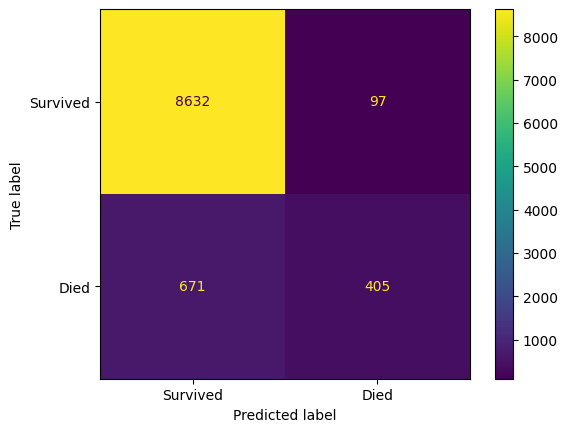

In [12]:
model.eval()
all_probs, all_labels = [], []
with torch.no_grad():
    for X_b, _, y_b in test_loader:
        logits, _ = model(X_b.to(DEVICE))
        all_probs.append(torch.sigmoid(logits).cpu().squeeze(-1))
        all_labels.append(y_b)

probs  = torch.cat(all_probs).numpy()
labels = torch.cat(all_labels).numpy()
preds  = (probs >= 0.5).astype(int)

from sklearn.metrics import classification_report, ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt

print(classification_report(labels, preds, target_names=["Survived", "Died"]))
ConfusionMatrixDisplay(confusion_matrix(labels, preds), display_labels=["Survived", "Died"]).plot()
plt.show()

In [13]:
print(pos_weight)

tensor([10.6361], device='cuda:0')


In [16]:
# get all predictions with indices
model.eval()
all_probs, all_labels, all_X = [], [], []
with torch.no_grad():
    for X_b, _, y_b in test_loader:
        logits, _ = model(X_b.to(DEVICE))
        all_probs.append(torch.sigmoid(logits).cpu().squeeze(-1))
        all_labels.append(y_b)
        all_X.append(X_b.cpu())

probs  = torch.cat(all_probs).numpy()
labels = torch.cat(all_labels).numpy()
preds  = (probs >= 0.3).astype(int)

# false negatives — died but predicted survived
fn_mask = (labels == 1) & (preds == 0)
fn_probs = probs[fn_mask]

print(f"Total Died       : {int(labels.sum())}")
print(f"Predicted Died   : {preds.sum()}")
print(f"False Negatives  : {fn_mask.sum()}")
print(f"\nFN prob stats (model confidence they survived):")
print(f"  mean  : {fn_probs.mean():.3f}")
print(f"  median: {np.median(fn_probs):.3f}")
print(f"  max   : {fn_probs.max():.3f}")

Total Died       : 1076
Predicted Died   : 958
False Negatives  : 497

FN prob stats (model confidence they survived):
  mean  : 0.126
  median: 0.115
  max   : 0.300


In [20]:
import pandas as pd

# all_X1 = torch.cat(all_X).numpy()  # (N, 48, 30)

# your feature names — replace with actual names
feature_names = all_features

# FN patient records — mean across 48 hours for each feature
fn_X    = all_X[fn_mask]          # (n_fn, 48, 30)
fn_mean = fn_X.mean(axis=1)       # (n_fn, 30) — avg over time

fn_df = pd.DataFrame(fn_mean, columns=feature_names)
fn_df["true_label"] = 1
fn_df["pred_prob"]  = fn_probs

print(f"False Negative patients: {len(fn_df)}")
fn_df.head(10)

False Negative patients: 497


,creatinine,glucose,sodium,potassium,hematocrit,wbc,heart_rate,sbp,dbp,mbp,...,time_since_last_sbp,time_since_last_dbp,time_since_last_mbp,time_since_last_respiratory_rate,time_since_last_temperature,time_since_last_spo2,time_since_last_age,time_since_last_gender,true_label,pred_prob
0,0.798015,-0.032305,1.303265,-0.108492,-0.673086,-0.010178,1.398305,0.014396,-0.036032,0.769387,...,0.295843,0.067775,-0.449805,0.295404,0.321047,-0.582356,0.0,0.0,1,0.074750
1,-0.109107,-0.076972,0.098050,0.144141,-1.445836,-0.018273,-0.082702,-0.001819,-0.004290,-0.276608,...,1.002519,0.655230,0.355993,1.002510,1.165216,0.221200,0.0,0.0,1,0.036780
2,0.003745,-0.021526,0.010058,-0.163000,0.009903,-0.004200,0.012895,-0.002317,0.026739,0.196375,...,2.186129,1.632716,-0.960144,2.186841,2.225909,-1.011616,0.0,0.0,1,0.093681
3,-0.168053,0.102851,-0.515140,0.087354,0.836614,0.025789,-0.928409,-0.002750,0.178702,1.387268,...,-0.439915,0.737088,-0.790926,-0.437892,-0.484751,-0.846717,0.0,0.0,1,0.162441
4,-0.138998,0.045448,0.372736,0.063590,0.741039,0.005083,-0.354312,0.001061,0.022559,-0.143074,...,-0.439915,1.151196,0.178717,-0.440802,-0.435417,0.098180,0.0,0.0,1,0.016188
5,0.045857,0.000820,1.424354,-0.058055,-0.757944,0.000065,-1.183320,0.000074,0.003153,-0.488962,...,-0.439915,-0.541348,-0.422945,-0.432072,-0.462825,-0.349403,0.0,0.0,1,0.115966
6,3.132575,0.018618,-0.082945,0.040864,-0.380780,0.009125,-0.425182,0.004766,0.181478,1.319258,...,-0.439915,-0.449859,-0.484723,-0.440802,-0.443639,-0.040544,0.0,0.0,1,0.129022
7,-0.425378,0.004008,-0.443638,-0.141548,-0.453750,0.004234,-1.014827,0.001772,0.113597,0.187654,...,-0.175275,-0.322256,0.173345,-0.176000,-0.029777,0.208113,0.0,0.0,1,0.004229
8,-0.755888,-0.053547,-0.282089,0.250322,-0.416095,-0.018023,-0.068858,0.012166,-0.199367,0.934433,...,-0.439915,2.061269,-0.154346,-0.440802,-0.566976,0.150529,0.0,0.0,1,0.209613
9,0.344297,-0.109339,-0.897201,0.052870,-1.065778,-0.010050,0.437007,-0.006456,0.191018,2.023694,...,-0.437007,-0.538940,0.036360,-0.437892,-0.410749,-0.441014,0.0,0.0,1,0.142236


In [21]:
tp_mask  = (labels == 1) & (preds == 1)
tp_mean  = all_X[tp_mask].mean(axis=1)
fn_mean2 = all_X[fn_mask].mean(axis=1)

compare_df = pd.DataFrame({
    "feature": feature_names,
    "FN_mean": fn_mean2.mean(axis=0),
    "TP_mean": tp_mean.mean(axis=0),
})
compare_df["difference"] = compare_df["TP_mean"] - compare_df["FN_mean"]
compare_df.sort_values("difference", ascending=False)

,feature,FN_mean,TP_mean,difference
26,time_since_last_temperature,-0.223260,0.393510,0.616771
2,sodium,0.085169,0.689896,0.604728
23,time_since_last_dbp,-0.064212,0.536263,0.600475
16,time_since_last_glucose,-0.062992,0.536904,0.599896
20,time_since_last_wbc,-0.062525,0.536168,0.598693
18,time_since_last_potassium,-0.231879,0.365164,0.597043
25,time_since_last_respiratory_rate,-0.234240,0.352024,0.586264
22,time_since_last_sbp,-0.232823,0.349681,0.582504
12,spo2,0.091538,0.569475,0.477937
6,heart_rate,0.115314,0.562641,0.447327


In [34]:
# are FN probs borderline or confidently wrong?
print(f"FN probs < 0.1  : {(fn_probs < 0.1).sum()}  (model very confident they survive)")
print(f"FN probs 0.1-0.2: {((fn_probs >= 0.1) & (fn_probs < 0.2)).sum()}")
print(f"FN probs 0.2-0.3: {((fn_probs >= 0.2) & (fn_probs < 0.3)).sum()}")
print(f"FN probs 0.3-0.5: {((fn_probs >= 0.3) & (fn_probs < 0.5)).sum()}")

FN probs < 0.1  : 228  (model very confident they survive)
FN probs 0.1-0.2: 135
FN probs 0.2-0.3: 134
FN probs 0.3-0.5: 0


In [22]:
import shap
import matplotlib.pyplot as plt
import pandas as pd

model.eval()

/home/rendred/Temporal/.venv-310/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


TFCAM(
  (input_proj): Linear(in_features=30, out_features=64, bias=True)
  (pos_enc): PositionalEncoding(
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (dual_attn): DualBiLSTMAttention(
    (lstm_alpha): LSTM(64, 64, batch_first=True, bidirectional=True)
    (fc_alpha): Linear(in_features=128, out_features=1, bias=True)
    (lstm_beta): LSTM(64, 64, batch_first=True, bidirectional=True)
    (fc_beta): Linear(in_features=128, out_features=30, bias=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (cross_attn): CrossFeatureAttention(
    (encoder): TransformerEncoder(
      (layers): ModuleList(
        (0-1): 2 x TransformerEncoderLayer(
          (self_attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
          )
          (linear1): Linear(in_features=64, out_features=256, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
          (linear2): Linear(in_features=256, out_features=64, b

In [26]:
class CoIShAPWrapper:
    def __init__(self, model, mask_full, device, T, batch_size=32):
        self.model      = model
        self.mask_full  = mask_full   # real mask (N, T)
        self.device     = device
        self.T          = T
        self.batch_size = batch_size
    
    def __call__(self, X_flat):
        n  = X_flat.shape[0]
        Fv = X_flat.shape[1] // self.T
        X  = X_flat.reshape(n, self.T, Fv)
        
        all_probs = []
        for i in range(0, n, self.batch_size):
            batch_X = X[i:i+self.batch_size]
            b       = batch_X.shape[0]
            
            # use real masks for this batch, cycling if needed
            mask_idx = np.arange(i, i+b) % len(self.mask_full)
            batch_m  = self.mask_full[mask_idx]
            
            X_t = torch.FloatTensor(batch_X).to(self.device)
            m_t = torch.BoolTensor(batch_m).to(self.device)
            
            with torch.no_grad():
                logits, _ = self.model(X_t)
                probs = torch.sigmoid(logits).cpu().numpy()
            all_probs.extend(probs)
        
        return np.array(all_probs)

In [27]:
np.random.seed(42)
dead_idx     = np.where(y_test == 1)[0]
survived_idx = np.where(y_test == 0)[0]

# background: mix of survived and died
bg_idx = np.concatenate([
    np.random.choice(survived_idx, 20, replace=False),
    np.random.choice(dead_idx,     10, replace=False)
])
X_bg_flat = X_test[bg_idx].reshape(len(bg_idx), -1)

# explain on deceased only
explain_idx    = np.random.choice(dead_idx, 50, replace=False)
X_explain_flat = X_test[explain_idx].reshape(len(explain_idx), -1)

print(f"Background: {len(bg_idx)}, Explain: {len(explain_idx)}")

Background: 30, Explain: 50


In [28]:
T = 48
wrapper   = CoIShAPWrapper(model, mask_test, DEVICE, T, batch_size=16)
explainer = shap.KernelExplainer(wrapper, X_bg_flat)

print("Computing SHAP values...")
shap_values = explainer.shap_values(X_explain_flat, nsamples=200)
print(f"SHAP values shape: {shap_values.shape}")


Computing SHAP values...


  0%|          | 0/50 [00:00<?, ?it/s]

100%|██████████| 50/50 [00:53<00:00,  1.07s/it]

SHAP values shape: (50, 1440, 1)


Top features: ['spo2', 'time_since_last_potassium', 'age', 'time_since_last_spo2', 'time_since_last_dbp']
Bottom features: ['time_since_last_age', 'time_since_last_gender']

SHAP FEATURE IMPORTANCE (deceased patients)
                         Feature  Mean SHAP  Mean |SHAP|
       time_since_last_potassium   0.000249     0.000374
            time_since_last_spo2   0.000227     0.000326
                            spo2   0.000257     0.000290
      time_since_last_creatinine   0.000115     0.000275
                          gender   0.000200     0.000275
                respiratory_rate   0.000199     0.000265
                      heart_rate   0.000196     0.000255
                             wbc   0.000198     0.000251
                             age   0.000239     0.000248
             time_since_last_sbp   0.000128     0.000248
                          sodium   0.000110     0.000248
             time_since_last_dbp   0.000219     0.000242
                     temperature   0.0001

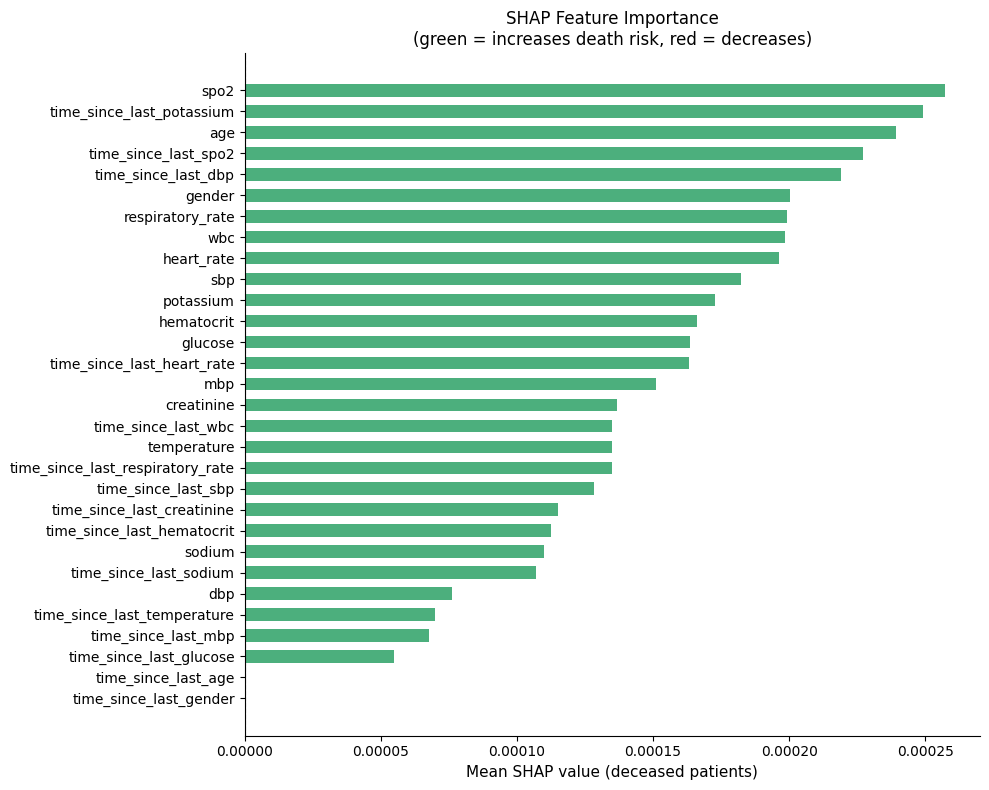

/tmp/ipykernel_18980/4012454537.py:45: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_per_feat,
/tmp/ipykernel_18980/4012454537.py:48: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


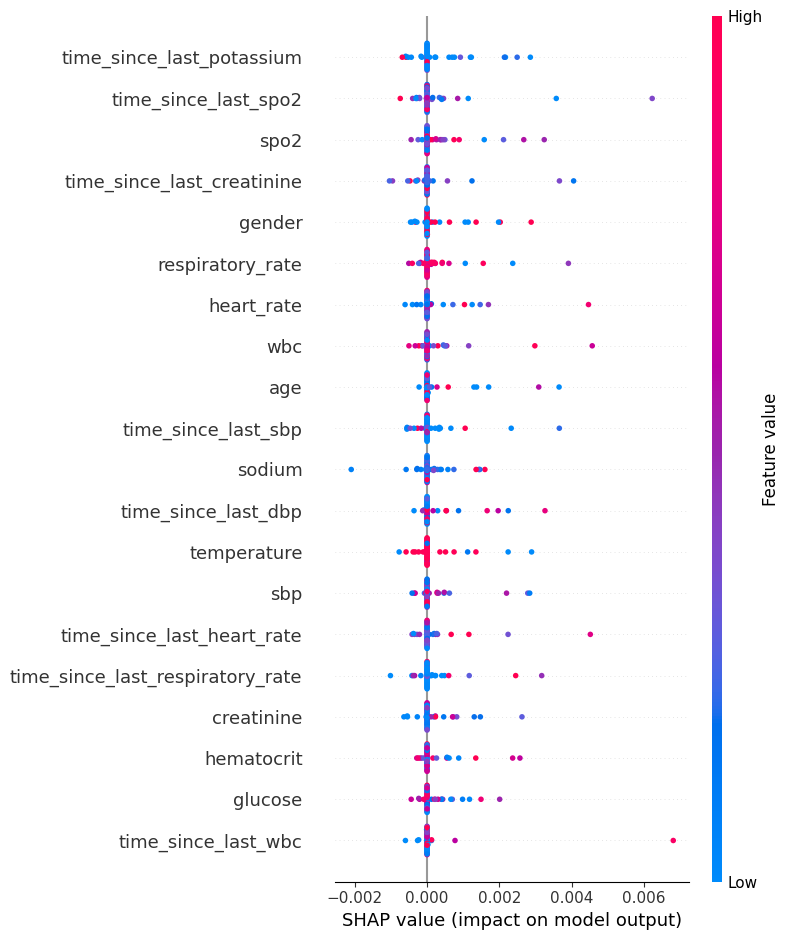


Feature | SHAP | Gradient | Agreement
-------------------------------------------------------
creatinine                         : SHAP +0.00014 | Grad +0.00014 | ✅
glucose                            : SHAP +0.00016 | Grad +0.00016 | ✅
sodium                             : SHAP +0.00011 | Grad +0.00011 | ✅
potassium                          : SHAP +0.00017 | Grad +0.00017 | ✅
hematocrit                         : SHAP +0.00017 | Grad +0.00017 | ✅
wbc                                : SHAP +0.00020 | Grad +0.00020 | ✅
heart_rate                         : SHAP +0.00020 | Grad +0.00020 | ✅
sbp                                : SHAP +0.00018 | Grad +0.00018 | ✅
dbp                                : SHAP +0.00008 | Grad +0.00008 | ✅
mbp                                : SHAP +0.00015 | Grad +0.00015 | ✅
respiratory_rate                   : SHAP +0.00020 | Grad +0.00020 | ✅
temperature                        : SHAP +0.00013 | Grad +0.00013 | ✅
spo2                               : SHAP +0.00026 | 

In [31]:
shap_reshaped   = shap_values.reshape(len(explain_idx), T, 30)  # (N, T, F)
shap_per_feat   = shap_reshaped.mean(axis=1)                    # (N, F)
mean_shap       = shap_per_feat.mean(axis=0)                    # (F,)
mean_abs_shap   = np.abs(shap_per_feat).mean(axis=0)            # (F,)

# ---- importance table ----
importance_df = pd.DataFrame({
    'Feature':    feature_names,
    'Mean SHAP':  mean_shap,
    'Mean |SHAP|': mean_abs_shap
}).sort_values('Mean |SHAP|', ascending=False)

avg_importance = {feat: float(shap_per_feat[:, i].mean()) 
                  for i, feat in enumerate(feature_names)}

# sort
sorted_features = sorted(avg_importance.items(), key=lambda x: x[1], reverse=True)
top_features    = [f for f, _ in sorted_features[:5]]
bottom_features = [f for f, _ in sorted_features[-2:]]

print("Top features:", top_features)
print("Bottom features:", bottom_features)
print("\n" + "="*60)
print("SHAP FEATURE IMPORTANCE (deceased patients)")
print("="*60)
print(importance_df.to_string(index=False))

# ---- bar plot ----
sorted_df = importance_df.sort_values('Mean SHAP')
colors    = ['#e05c5c' if v < 0 else '#4caf7d' for v in sorted_df['Mean SHAP']]

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(sorted_df['Feature'], sorted_df['Mean SHAP'], color=colors, edgecolor='none', height=0.6)
ax.axvline(x=0, color='gray', linewidth=0.8, linestyle='--')
ax.set_xlabel('Mean SHAP value (deceased patients)', fontsize=11)
ax.set_title('SHAP Feature Importance\n(green = increases death risk, red = decreases)', fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
# plt.savefig('shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# ---- summary plot ----
plt.figure(figsize=(12, 10))
shap.summary_plot(shap_per_feat, 
                  X_test[explain_idx].reshape(len(explain_idx), T, 30).mean(axis=1),
                  feature_names=feature_names, show=False)
plt.tight_layout()
# plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

# ---- comparison with gradient importance ----
print("\nFeature | SHAP | Gradient | Agreement")
print("-" * 55)
for feat in feature_names:
    idx      = feature_names.index(feat)
    shap_val = mean_shap[idx]
    grad_val = avg_importance.get(feat, 0)
    agree    = '✅' if np.sign(shap_val) == np.sign(grad_val) else '❌'
    print(f"{feat:35s}: SHAP {shap_val:+.5f} | Grad {grad_val:+.5f} | {agree}")